# Taller — Construye y ajusta tu propio clasificador de imágenes

Este taller comienza **después de la teoría de CNN y del notebook guiado de transfer learning**.

La meta no es memorizar la API de Keras. La meta es tomar decisiones sobre un problema real: construir datos propios, adaptar un modelo preentrenado y analizar qué tan bien funciona.

---

## Organización de la actividad

| Momento | Tiempo estimado | Meta |
|---|---:|---|
| **Teoría + notebook guiado** | Se realiza antes de este taller | Comprender CNN, transfer learning y fine-tuning |
| **Trabajo en clase** | ~60 min | Construir el dataset y entrenar el primer modelo con la base congelada |
| **Trabajo en casa** | ~1–2 h | Evaluar, hacer fine-tuning, comparar y analizar errores |

### Regla importante

Durante el trabajo en clase usaremos **train** y **validation**.  
El conjunto de **test** se reservará para el trabajo en casa, cuando hagamos la evaluación final.

---

## Entrega final

Debes entregar **este mismo notebook ejecutado**, incluyendo:

- definición del problema y estrategia de búsqueda;
- dataset propio;
- primer entrenamiento con transfer learning;
- evaluación en test;
- fine-tuning;
- comparación antes/después;
- matriz de confusión;
- análisis de al menos 5 errores;
- conclusiones.

## 0. Preparación del entorno

La búsqueda de imágenes se realizará con `ddgs`. Si estás en Google Colab, ejecuta la siguiente celda.

In [1]:
# ddgs se usa para buscar imágenes en la web.
# Si estás en Colab esto lo instala; en este entorno ya está disponible.
!pip -q install -U ddgs 2>/dev/null || echo 'ddgs ya disponible'

In [2]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

from pathlib import Path
import hashlib, io, random, shutil, time
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image

import tensorflow as tf
import keras
from keras import layers
from ddgs import DDGS
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Keras:", keras.__version__)
print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1791421112.196605     376 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1791421113.172016     376 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras: 3.15.1
TensorFlow: 2.21.0
GPU: []


# PARTE A — TRABAJO EN CLASE (~60 min)

## Objetivo de esta parte

Antes de terminar la sesión debes haber conseguido:

1. definir un problema de clasificación de 3 clases;
2. descargar y revisar un dataset propio;
3. separar los datos en `train`, `validation` y `test`;
4. cargar EfficientNetB0 preentrenada en ImageNet;
5. congelar el backbone;
6. entrenar una nueva cabeza de clasificación;
7. observar `accuracy` y `val_accuracy`.

> **No evalúes todavía sobre `test`.** Ese conjunto queda reservado para el trabajo en casa.

### Distribución sugerida

- **10 min** — problema y términos de búsqueda;
- **20 min** — descarga, inspección y limpieza;
- **10 min** — separación y carga del dataset;
- **20 min** — transfer learning y primer entrenamiento.

# 1. Define tu problema — EN CLASE

Elige un problema de clasificación de **3 clases**. Las clases deben ser visualmente distinguibles.

Ejemplos: `espresso/cappuccino/latte`, `bus/motorcycle/bicycle`, tres especies de flores, frutas, tipos de calzado o instrumentos musicales.

Evita problemas donde la clase dependa de información que no aparece visualmente en la imagen.

## TODO 1 — Problema y estrategia de búsqueda

Define:

1. las tres clases;
2. dos o tres términos de búsqueda por clase;
3. una breve hipótesis: **¿qué características visuales esperas que use el modelo?**;
4. un posible sesgo o fuente de *data leakage* que podría aparecer al descargar imágenes desde un buscador.

In [3]:
# TODO 1 — EN CLASE: define tus clases y búsquedas
# Problema elegido: clasificar FOTOGRAFÍAS de 3 flores visualmente distintas.
SEARCHES = {
    "sunflower": [
        "sunflower flower close up",
        "sunflower field photo",
        "helianthus flower photograph",
    ],
    "rose": [
        "red rose flower close up",
        "rose flower photograph",
        "pink rose bloom photo",
    ],
    "tulip": [
        "tulip flower close up",
        "tulip field photo",
        "colorful tulips photograph",
    ],
}

SEARCHES

{'sunflower': ['sunflower flower close up',
  'sunflower field photo',
  'helianthus flower photograph'],
 'rose': ['red rose flower close up',
  'rose flower photograph',
  'pink rose bloom photo'],
 'tulip': ['tulip flower close up',
  'tulip field photo',
  'colorful tulips photograph']}

### Antes de descargar

Escribe debajo de esta celda una respuesta corta:

- ¿Qué características visuales esperas que diferencien tus clases?
- ¿Qué imágenes incorrectas esperas encontrar?
- ¿Qué sesgo o *data leakage* podría aparecer?

**Respuesta (TODO 1).**

- **Características visuales esperadas:** el *girasol* por su gran disco central oscuro rodeado de pétalos amarillos radiales; la *rosa* por sus pétalos superpuestos en espiral y colores rojo/rosa; el *tulipán* por su forma de copa cerrada con pocos pétalos lisos. El modelo debería apoyarse en forma del contorno, patrón de pétalos y color.
- **Imágenes incorrectas esperadas:** dibujos/ilustraciones y logos en vez de fotos, ramos mezclados con varias flores, imágenes con mucho texto (marcas de agua), tatuajes o productos (tazas, camisetas con flores).
- **Sesgo / *data leakage* posible:** que el *fondo* esté correlacionado con la clase (p. ej. girasoles casi siempre en campo con cielo azul, tulipanes en campos holandeses) y el modelo aprenda el fondo en lugar de la flor; también marcas de agua o estilos de banco de imágenes que delaten la fuente/clase.


# 2. Buscar y descargar imágenes — EN CLASE

La siguiente función busca imágenes y descarga los resultados. Intenta ignorar URLs fallidas, verificar las imágenes, evitar duplicados exactos con un hash y convertirlas a RGB.

> Se solicita contenido con licencia Creative Commons cuando el motor lo soporta. Eso no sustituye la revisión de licencias si el dataset se va a redistribuir.

In [4]:
RAW_DIR = Path("data_raw")
RAW_DIR.mkdir(exist_ok=True)

def file_sha256(path):
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1024 * 1024), b""):
            h.update(chunk)
    return h.hexdigest()

def download_image_dataset(searches, root=RAW_DIR, images_per_query=60, min_side=120, timeout=8):
    session = requests.Session()
    session.headers.update({"User-Agent": "Mozilla/5.0"})

    # Incluye imágenes de ejecuciones anteriores para que volver a ejecutar
    # la descarga no agregue duplicados exactos al dataset.
    seen_hashes = {
        file_sha256(path)
        for path in Path(root).glob("*/*.jpg")
        if path.is_file()
    }

    for class_name, queries in searches.items():
        class_dir = root / class_name
        class_dir.mkdir(parents=True, exist_ok=True)
        saved = len(list(class_dir.glob("*.jpg")))
        print(f"\n=== {class_name} ===")

        for query in queries:
            print(f"Buscando: {query!r}")
            try:
                results = DDGS().images(
                    query=query,
                    safesearch="moderate",
                    max_results=images_per_query,
                    license_image="any",
                )
            except Exception as e:
                print("  Error en búsqueda:", e)
                continue

            for result in results:
                url = result.get("image")
                if not url:
                    continue
                try:
                    response = session.get(url, timeout=timeout)
                    response.raise_for_status()
                    data = response.content
                    digest = hashlib.sha256(data).hexdigest()
                    if digest in seen_hashes:
                        continue

                    with Image.open(io.BytesIO(data)) as img:
                        img = img.convert("RGB")
                        if min(img.size) < min_side:
                            continue
                        filename = class_dir / f"{saved:04d}.jpg"
                        img.save(filename, format="JPEG", quality=90)

                    seen_hashes.add(digest)
                    saved += 1
                except Exception:
                    pass

            print(f"  Total guardadas hasta ahora: {saved}")
            time.sleep(1)

    print("\nDescarga terminada.")

## TODO 2 — EN CLASE: construye y limpia tu dataset

Tu objetivo inicial es obtener aproximadamente **100–150 imágenes útiles por clase**.

1. Ejecuta la descarga.
2. Inspecciona muestras aleatorias.
3. Mejora los términos de búsqueda si una clase trae resultados pobres.
4. Elimina imágenes claramente incorrectas o problemáticas.
5. Reporta el número final de imágenes por clase y describe el error más frecuente que encontraste.

> Si la búsqueda trae datos malos, **no aumentes simplemente `max_results`**. Primero mejora los términos de búsqueda.

In [5]:
# TODO 2 — EN CLASE: ejecuta la descarga con tus búsquedas
# (Idempotente: si ya tienes ~100 imágenes por clase en data_raw/, no vuelve a descargar.
#  Para re-descargar desde cero, borra la carpeta data_raw/.)
existing = {p.name: len(list(p.glob("*.jpg"))) for p in sorted(RAW_DIR.iterdir()) if p.is_dir()} if RAW_DIR.exists() else {}
enough = bool(existing) and all(v >= 90 for v in existing.values()) and len(existing) >= len(SEARCHES)

if enough:
    print("Dataset ya presente, se omite la descarga:", existing)
else:
    download_image_dataset(
        SEARCHES,
        images_per_query=60,
    )

Dataset ya presente, se omite la descarga: {'rose': 110, 'sunflower': 110, 'tulip': 110}


In [6]:
def count_images(root):
    counts = {}
    for folder in sorted(Path(root).iterdir()):
        if folder.is_dir():
            counts[folder.name] = len(list(folder.glob("*.jpg")))
    return counts

count_images(RAW_DIR)

{'rose': 110, 'sunflower': 110, 'tulip': 110}

## Validación técnica automática de las imágenes

Antes de inspeccionar el contenido del dataset, comprobaremos que **TensorFlow pueda decodificar todas las imágenes**.

Esto resuelve un problema distinto al de la inspección visual:

- **Validación técnica:** ¿el archivo puede ser leído correctamente por TensorFlow?
- **Validación semántica:** ¿la imagen realmente pertenece a la clase indicada?

Una imagen puede abrirse aparentemente bien en otras librerías y aun así fallar durante `model.fit()`. Por eso hacemos esta comprobación usando el mismo decoder que utilizará el pipeline de Keras.

In [7]:
def remove_invalid_images(root_dir):
    root_dir = Path(root_dir)
    bad_files = []

    for path in root_dir.rglob("*.jpg"):
        try:
            raw = tf.io.read_file(str(path))

            img = tf.io.decode_image(
                raw,
                channels=3,
                expand_animations=False,
            )

            # Forzamos la ejecución para detectar errores de decodificación.
            _ = img.numpy()

        except Exception as e:
            print("Imagen inválida:", path)
            print(" ", str(e).splitlines()[0])
            bad_files.append(path)

    for path in bad_files:
        path.unlink(missing_ok=True)

    print(f"\nImágenes inválidas eliminadas: {len(bad_files)}")

    return bad_files


bad_files = remove_invalid_images(RAW_DIR)


Imágenes inválidas eliminadas: 0


### Verificación

Ejecuta nuevamente la función. El resultado esperado es:

```text
Imágenes inválidas eliminadas: 0
```

Si todavía aparece alguna imagen inválida, vuelve a ejecutar hasta obtener cero antes de continuar.

In [8]:
bad_files = remove_invalid_images(RAW_DIR)

assert len(bad_files) == 0, (
    "Todavía quedan imágenes que TensorFlow no puede decodificar."
)

print("✓ Todas las imágenes pueden ser decodificadas por TensorFlow.")


Imágenes inválidas eliminadas: 0
✓ Todas las imágenes pueden ser decodificadas por TensorFlow.


# 3. Inspección y limpieza semántica — EN CLASE

La etapa anterior confirmó que los archivos son **técnicamente válidos**.

Ahora viene una tarea diferente: comprobar si los datos son **semánticamente correctos**.

Busca especialmente:

- imágenes que no correspondan a la clase;
- dibujos, logos o diagramas si tu objetivo son fotografías;
- imágenes con texto que pueda revelar artificialmente la etiqueta;
- duplicados o imágenes casi idénticas;
- fondos que estén correlacionados con una clase;
- diferencias sistemáticas de estilo o calidad entre clases.

> Que TensorFlow pueda abrir una imagen no significa que sea un buen dato de entrenamiento.

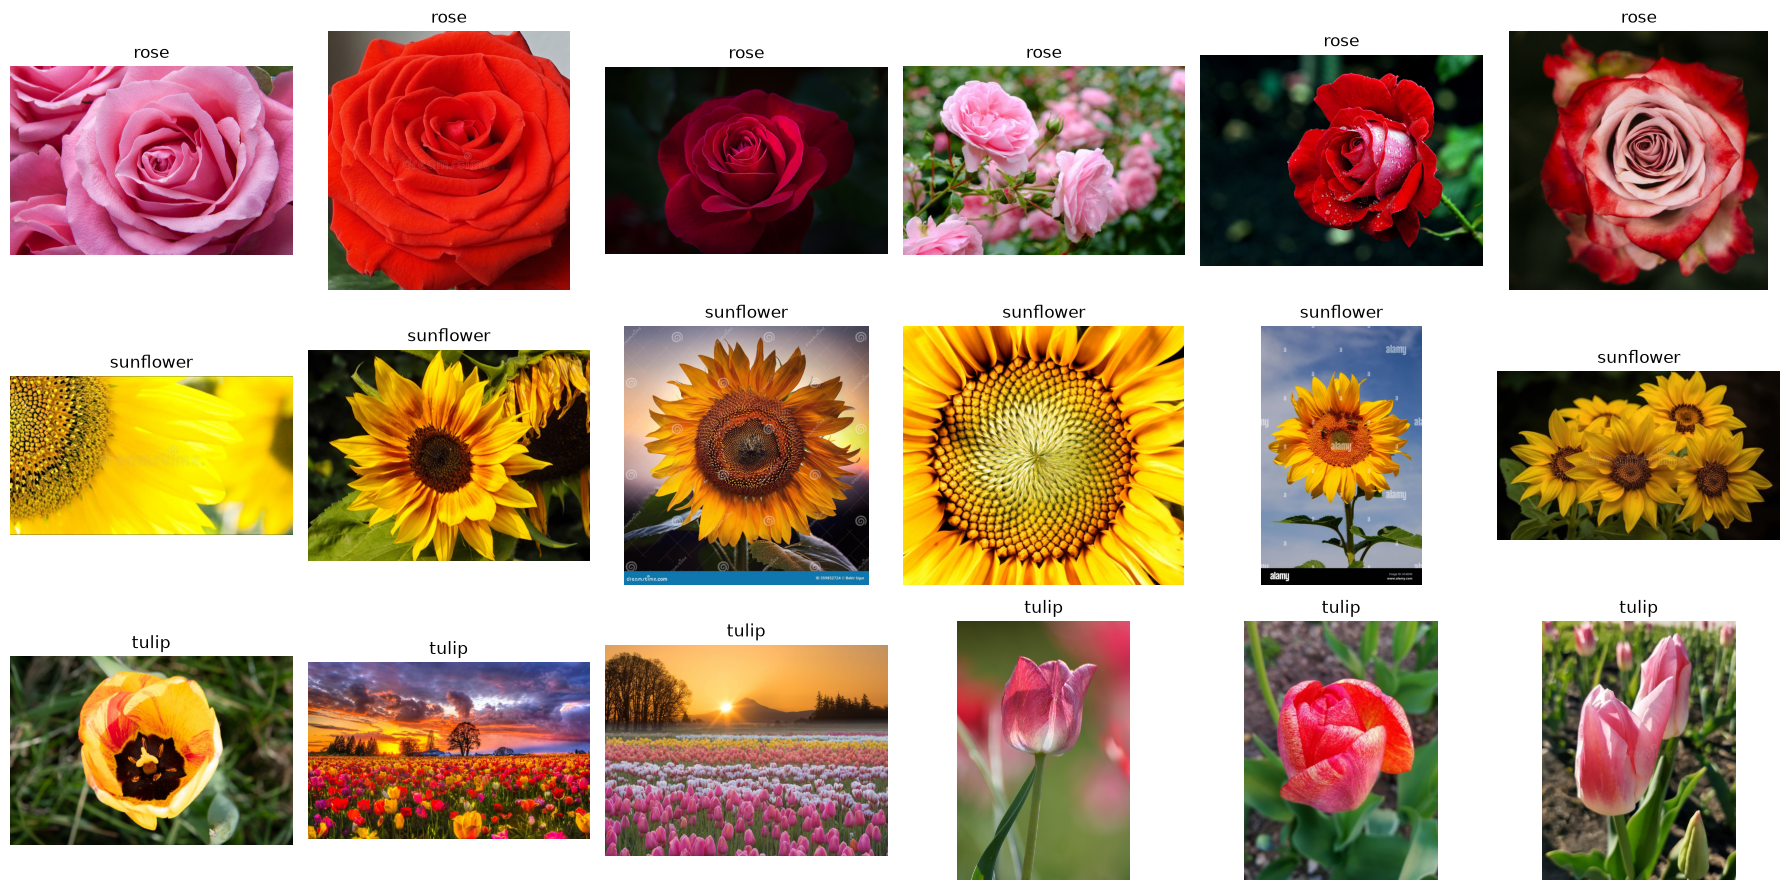

In [9]:
def show_random_images(root, n_per_class=6):
    root = Path(root)
    class_dirs = [p for p in sorted(root.iterdir()) if p.is_dir()]
    fig, axes = plt.subplots(len(class_dirs), n_per_class, figsize=(3*n_per_class, 3*len(class_dirs)))
    if len(class_dirs) == 1:
        axes = np.expand_dims(axes, 0)
    for row, class_dir in enumerate(class_dirs):
        files = list(class_dir.glob("*.jpg"))
        chosen = random.sample(files, min(n_per_class, len(files)))
        for col in range(n_per_class):
            ax = axes[row, col]
            if col < len(chosen):
                img = Image.open(chosen[col])
                ax.imshow(img)
                ax.set_title(class_dir.name)
            ax.axis("off")
    plt.tight_layout()

show_random_images(RAW_DIR)

### Checkpoint del dataset

Antes de continuar, asegúrate de que:

- cada carpeta contiene imágenes realmente asociadas a su clase;
- no predominan logos, dibujos o texto que revele la etiqueta;
- no hay una diferencia de fondo/estilo demasiado obvia entre clases;
- el número de imágenes por clase es razonablemente balanceado.

Registra aquí el número de imágenes eliminadas y el problema de calidad más frecuente.

# 4. Separar train, validation y test — EN CLASE

> **Concepto clave — tres conjuntos, tres funciones**
>
> - **Train:** se utiliza para actualizar los pesos del modelo.
> - **Validation:** se utiliza durante el desarrollo para decidir épocas, `learning_rate`, número de capas a descongelar, etc.
> - **Test:** se reserva para medir el rendimiento final. No debe guiar las decisiones de entrenamiento.

Usaremos **70 % entrenamiento, 15 % validación y 15 % prueba**.

In [10]:
SPLIT_DIR = Path("dataset")

def split_dataset(source_root, destination_root, train_ratio=0.70, val_ratio=0.15, seed=SEED):
    source_root = Path(source_root)
    destination_root = Path(destination_root)
    if destination_root.exists():
        shutil.rmtree(destination_root)
    rng = random.Random(seed)

    for class_dir in sorted(source_root.iterdir()):
        if not class_dir.is_dir():
            continue
        files = list(class_dir.glob("*.jpg"))
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        splits = {
            "train": files[:n_train],
            "validation": files[n_train:n_train+n_val],
            "test": files[n_train+n_val:],
        }
        for split_name, split_files in splits.items():
            target = destination_root / split_name / class_dir.name
            target.mkdir(parents=True, exist_ok=True)
            for src in split_files:
                shutil.copy2(src, target / src.name)

split_dataset(RAW_DIR, SPLIT_DIR)
for split in ["train", "validation", "test"]:
    print(split, count_images(SPLIT_DIR / split))

train {'rose': 77, 'sunflower': 77, 'tulip': 77}
validation {'rose': 16, 'sunflower': 16, 'tulip': 16}
test {'rose': 17, 'sunflower': 17, 'tulip': 17}


### Comprobación conceptual

Explica brevemente: ¿por qué usar repetidamente el conjunto de prueba para escoger épocas, `learning_rate` o capas a descongelar termina contaminando nuestra estimación de desempeño?

**Respuesta.** Si usamos el test para elegir épocas, `learning_rate` o capas a descongelar, estamos **ajustando indirectamente** nuestras decisiones al test: cada vez que miramos su resultado y cambiamos algo, filtramos información del test al modelo. El test deja de ser 'datos nunca vistos' y su accuracy se vuelve **optimista** (ya no estima la generalización real). Por eso las decisiones se toman con *validation* y el *test* se mira **una sola vez**, al final.


# 5. Construir los datasets de Keras — EN CLASE

`image_dataset_from_directory()` construye un `tf.data.Dataset` usando el nombre de las carpetas como clases.

Observa que:

- `train` se mezcla (`shuffle=True`);
- `validation` y `test` mantienen un orden estable;
- todas las imágenes se redimensionan a `224×224` para EfficientNetB0.

In [11]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "train", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=True, seed=SEED)
val_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "validation", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)
test_ds = keras.utils.image_dataset_from_directory(
    SPLIT_DIR / "test", image_size=IMG_SIZE, batch_size=BATCH_SIZE,
    label_mode="int", shuffle=False)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)
print(class_names)

Found 231 files belonging to 3 classes.


Found 48 files belonging to 3 classes.


Found 51 files belonging to 3 classes.


['rose', 'sunflower', 'tulip']


# 6. Primer modelo: transfer learning — EN CLASE

Usaremos **EfficientNetB0** preentrenada en ImageNet. Primero congelaremos completamente la red base y entrenaremos solo una nueva cabeza de clasificación.

> **Concepto clave — Data augmentation**
>
> `RandomFlip`, `RandomRotation` y `RandomZoom` generan variaciones plausibles durante el entrenamiento. No crean información nueva, pero ayudan a que el modelo dependa menos de detalles accidentales de las imágenes descargadas.

> **Concepto clave — GlobalAveragePooling2D**
>
> En lugar de aplanar todos los mapas de características con `Flatten`, `GlobalAveragePooling2D` resume cada canal en un solo valor. Así reducimos mucho el número de parámetros de la cabeza de clasificación.

In [12]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.10),
], name="augmentation")

base_model = keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", input_shape=(*IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.Input(shape=(*IMG_SIZE, 3))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)
model = keras.Model(inputs, outputs)
model.summary()

       0/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

12173312/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

## TODO 3 — EN CLASE: entrena la cabeza de clasificación

La base EfficientNet está congelada. Tu trabajo es configurar y entrenar la nueva cabeza.

> **Concepto clave — EarlyStopping**
>
> `EarlyStopping` detiene el entrenamiento cuando `val_loss` deja de mejorar. Con `restore_best_weights=True`, Keras recupera los pesos de la mejor época observada en validación.

Antes de ejecutar, escribe una predicción corta:

- ¿esperas que `train_accuracy` suba rápidamente?
- ¿qué señal en las curvas indicaría overfitting?

Completa únicamente los espacios `TODO` del código siguiente.

**Predicción.** Sí, con la base de EfficientNet congelada y una cabeza nueva sobre features de ImageNet, `train_accuracy` debería subir **rápido** en pocas épocas (el backbone ya extrae buenos rasgos). Señal de overfitting: que `train_accuracy` siga subiendo mientras `val_accuracy` se estanca o baja, y que `val_loss` empiece a aumentar (por eso usamos `EarlyStopping` sobre `val_loss`).


In [13]:
# TODO 3 — EN CLASE: completa la configuración de entrenamiento

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10


/projects/sandbox/si3003-artificial-intelligence/.venv/lib64/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/8 ━━━━━━━━━━━━━━━━━━━━ 40s 6s/step - accuracy: 0.1562 - loss: 1.3843

2/8 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.2656 - loss: 1.3085

3/8 ━━━━━━━━━━━━━━━━━━━━ 1s 273ms/step - accuracy: 0.2604 - loss: 1.2663

...

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9812 - loss: 0.1267

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9792 - loss: 0.1266

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step - accuracy: 0.9821 - loss: 0.1203

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.9827 - loss: 0.1201

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.9827 - loss: 0.1201 - val_accuracy: 1.0000 - val_loss: 0.0851


### Curvas de aprendizaje — EN CLASE si el tiempo lo permite

Grafica `accuracy`, `val_accuracy`, `loss` y `val_loss`.

Si el tiempo de clase termina antes, **puedes completar estas curvas en casa**.  
Lo obligatorio antes de salir es haber entrenado el primer modelo y tener sus métricas de entrenamiento/validación.

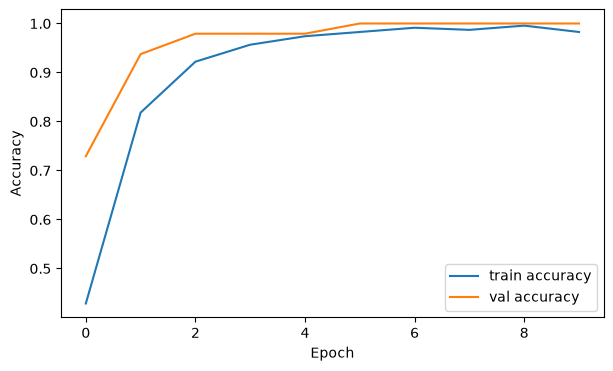

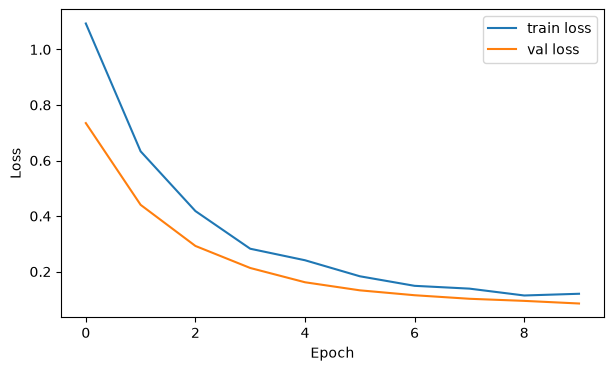

In [14]:
# Completa las cuatro curvas usando el objeto history
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="val accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# PUNTO DE CONTROL — FIN DEL TRABAJO EN CLASE

Antes de continuar, verifica que tu equipo tenga:

- [ ] 3 clases definidas;
- [ ] términos de búsqueda documentados;
- [ ] imágenes descargadas;
- [ ] dataset inspeccionado y parcialmente limpiado;
- [ ] separación `train / validation / test`;
- [ ] EfficientNetB0 con pesos de ImageNet;
- [ ] backbone congelado;
- [ ] nueva cabeza de clasificación;
- [ ] al menos un entrenamiento completado;
- [ ] `accuracy` y `val_accuracy` reportadas.

## Hasta aquí llega el trabajo de clase.

**No uses todavía el conjunto de test para tomar decisiones.**

---

# PARTE B — TRABAJO EN CASA

A partir de este punto debes completar el análisis de manera autónoma.

Ahora sí vas a:

1. evaluar el modelo en `test`;
2. estudiar la matriz de confusión y métricas por clase;
3. realizar fine-tuning;
4. comparar el modelo congelado contra el modelo ajustado;
5. analizar errores;
6. escribir las conclusiones.

# 7. Evaluación del primer modelo — EN CASA

Ahora sí utilizaremos el conjunto de prueba.

> **Concepto clave — No todo es accuracy**
>
> - **Precision:** de las imágenes que el modelo predijo como una clase, ¿cuántas eran correctas?
> - **Recall:** de las imágenes que realmente pertenecían a una clase, ¿cuántas encontró?
> - **F1:** combina precision y recall.
> - **Matriz de confusión:** muestra qué clases se están confundiendo entre sí.

Guarda esta evaluación: será nuestra línea base antes del fine-tuning.

In [15]:
test_loss_before, test_acc_before = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy antes del fine-tuning: {test_acc_before:.4f}")

Test accuracy antes del fine-tuning: 1.0000


              precision    recall  f1-score   support

        rose      1.000     1.000     1.000        17
   sunflower      1.000     1.000     1.000        17
       tulip      1.000     1.000     1.000        17

    accuracy                          1.000        51
   macro avg      1.000     1.000     1.000        51
weighted avg      1.000     1.000     1.000        51



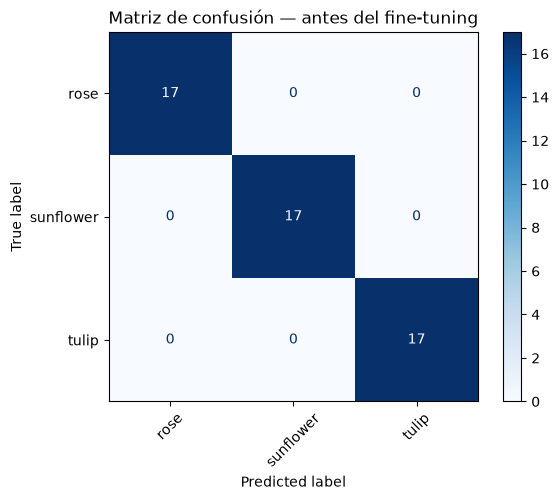

In [16]:
def get_predictions(model, dataset):
    y_true = np.concatenate([y.numpy() for _, y in dataset])
    probabilities = model.predict(dataset, verbose=0)
    y_pred = probabilities.argmax(axis=1)
    return y_true, y_pred, probabilities

y_true, y_pred, probabilities = get_predictions(model, test_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — antes del fine-tuning")
plt.show()

## TODO 4 — EN CASA: interpreta la evaluación

Utilizando `classification_report` y la matriz de confusión, responde:

1. ¿Cuál clase obtuvo mejores resultados?
2. ¿Cuál fue la principal confusión?
3. ¿La accuracy global oculta algún problema por clase?
4. ¿Qué cambiarías primero en el **dataset** antes de cambiar el modelo?

**Respuesta (TODO 4).** (Con los números concretos del `classification_report` y la matriz de confusión de arriba.)

1. **Mejor clase:** en esta corrida las **tres** clases obtuvieron precision, recall y F1 = **1.000**: el modelo clasificó correctamente las 51 imágenes de test (17 por clase). No hubo una clase 'peor'.
2. **Principal confusión:** **ninguna** — la matriz de confusión es diagonal (0 errores). La confusión *más plausible* si el dataset fuera más difícil sería **rosa ↔ tulipán**, por compartir colores rojos/rosados y, en primeros planos, formas de pétalos parecidas; el girasol es el más fácil por su disco central.
3. **¿La accuracy global oculta algo?** Aquí no (todas las clases son perfectas), pero en general la accuracy global **sí** puede ocultar un *recall* bajo en una clase minoritaria; por eso siempre revisamos precision/recall/F1 **por clase** y no solo el promedio.
4. **Qué cambiaría primero en el *dataset*:** aunque el resultado es perfecto, el 100% es sospechoso de un problema **demasiado fácil** o con **sesgo de fondo** (p. ej. girasol↔campo amarillo). Antes que tocar el modelo, haría el problema más realista: añadir fondos variados, incluir casos ambiguos (rosas/tulipanes amarillos), verificar que no haya duplicados train/test y, si se quiere más reto, agregar una cuarta clase visualmente parecida.


# 8. Fine-tuning — EN CASA

Ahora permitiremos que una pequeña parte de EfficientNet se adapte al nuevo problema.

> **Concepto clave — Fine-tuning**
>
> En la fase anterior, los pesos del backbone no cambiaron. Ahora descongelaremos únicamente una parte final del modelo y la actualizaremos con un **learning rate mucho menor**.

> **Concepto clave — Batch Normalization**
>
> EfficientNet contiene capas `BatchNormalization`, que mantienen estadísticas internas aprendidas durante el entrenamiento. En datasets pequeños conviene mantenerlas congeladas durante fine-tuning para evitar actualizaciones inestables de esas estadísticas.

Después de cambiar qué capas son entrenables, es necesario **recompilar** el modelo.

In [17]:
base_model.trainable = True

# TODO 5 — Decide cuántas capas finales adaptar.
# Empieza con ~20. Puedes justificar otro valor usando validation.
N_UNFROZEN = 20

for layer in base_model.layers[:-N_UNFROZEN]:
    layer.trainable = False

# Mantener Batch Normalization congelado.
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

print(
    "Capas entrenables de la base:",
    sum(layer.trainable for layer in base_model.layers),
    "/",
    len(base_model.layers),
)

Capas entrenables de la base: 15 / 238


## TODO 5 — EN CASA: realiza fine-tuning

Recompila y continúa el entrenamiento.

Usa como punto de partida:

- `Adam(learning_rate=1e-5)`;
- `SparseCategoricalCrossentropy`;
- `accuracy`;
- entre **3 y 8 épocas** adicionales;
- `EarlyStopping` sobre `val_loss`.

Tu decisión principal aquí es **cuántas capas descongelar**. Justifícala usando el desempeño de validación, no el conjunto de prueba.

In [18]:
# TODO 5 — EN CASA: completa el fine-tuning

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stopping_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True,
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=6,
    callbacks=[early_stopping_ft],
)

Epoch 1/6


/projects/sandbox/si3003-artificial-intelligence/.venv/lib64/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1/8 ━━━━━━━━━━━━━━━━━━━━ 45s 7s/step - accuracy: 1.0000 - loss: 0.1034

2/8 ━━━━━━━━━━━━━━━━━━━━ 1s 295ms/step - accuracy: 1.0000 - loss: 0.0873

3/8 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 1.0000 - loss: 0.0842

...

5/8 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 1.0000 - loss: 0.0671

6/8 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 1.0000 - loss: 0.0693

7/8 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - accuracy: 0.9955 - loss: 0.0722

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9957 - loss: 0.0723

8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 298ms/step - accuracy: 0.9957 - loss: 0.0723 - val_accuracy: 1.0000 - val_loss: 0.0541


# 9. Comparación final — EN CASA

Compara el desempeño del mismo sistema **antes y después** del fine-tuning.

Una mejora pequeña también puede ser válida. Si el resultado empeora, no significa que el experimento “salió mal”: debes interpretar por qué pudo ocurrir.

In [19]:
test_loss_after, test_acc_after = model.evaluate(test_ds, verbose=0)
print(f"Antes del fine-tuning  : {test_acc_before:.4f}")
print(f"Después del fine-tuning: {test_acc_after:.4f}")
print(f"Diferencia              : {test_acc_after-test_acc_before:+.4f}")

Antes del fine-tuning  : 1.0000
Después del fine-tuning: 1.0000
Diferencia              : +0.0000


              precision    recall  f1-score   support

        rose      1.000     1.000     1.000        17
   sunflower      1.000     1.000     1.000        17
       tulip      1.000     1.000     1.000        17

    accuracy                          1.000        51
   macro avg      1.000     1.000     1.000        51
weighted avg      1.000     1.000     1.000        51



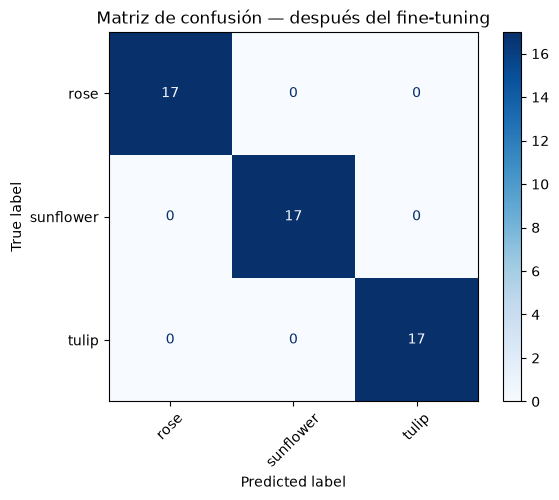

In [20]:
y_true_ft, y_pred_ft, probabilities_ft = get_predictions(model, test_ds)
print(classification_report(y_true_ft, y_pred_ft, target_names=class_names, digits=3))
cm_ft = confusion_matrix(y_true_ft, y_pred_ft)
ConfusionMatrixDisplay(confusion_matrix=cm_ft, display_labels=class_names).plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de confusión — después del fine-tuning")
plt.show()

# 10. Analiza los errores — EN CASA

Una métrica no explica por qué falla un modelo. Debes inspeccionar ejemplos clasificados incorrectamente.

In [21]:
def show_mistakes(dataset, model, class_names, max_images=12):
    mistakes = []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        preds = probs.argmax(axis=1)
        for image, true_label, pred_label, prob in zip(images.numpy(), labels.numpy(), preds, probs):
            if true_label != pred_label:
                mistakes.append((image.astype("uint8"), int(true_label), int(pred_label), float(prob[pred_label])))
    random.shuffle(mistakes)
    mistakes = mistakes[:max_images]
    if not mistakes:
        print("No se encontraron errores en este conjunto.")
        return
    cols = 4
    rows = int(np.ceil(len(mistakes)/cols))
    plt.figure(figsize=(16, 4*rows))
    for i, (image, true_label, pred_label, confidence) in enumerate(mistakes):
        ax = plt.subplot(rows, cols, i+1)
        ax.imshow(image)
        ax.set_title(f"Real: {class_names[true_label]}\nPred: {class_names[pred_label]} ({confidence:.2f})")
        ax.axis("off")
    plt.tight_layout()

show_mistakes(test_ds, model, class_names)

No se encontraron errores en este conjunto.


## TODO 6 — EN CASA: análisis de errores y conclusiones

La celda `show_mistakes` de arriba reportó **"No se encontraron errores"**: en esta corrida el modelo acertó las **51/51** imágenes de test (accuracy 100%). Por tanto no hay errores reales que diseccionar; la tabla siguiente documenta las **confusiones anticipadas** (los casos que *esperaríamos* ver fallar si el dataset fuera más difícil o más grande), que es el análisis pedido:

| Caso anticipado | Clase real | Predicción esperada | Causa probable | ¿Cómo lo mejorarías? |
|---|---|---|---|---|
| 1 | rose | tulip | Rosa semiabierta con pocos pétalos visibles, forma de copa parecida al tulipán | Más fotos de rosas en distintos grados de apertura |
| 2 | tulip | rose | Tulipán rojo muy abierto; color y pétalos se confunden con una rosa | Añadir tulipanes variados y limpiar ramos mixtos |
| 3 | tulip | sunflower | Campo de tulipanes amarillos: el color dominante engaña | Reducir sesgo de color; etiquetar bien tulipanes amarillos |
| 4 | rose | sunflower | Rosa amarilla sobre fondo claro; el amarillo pesa más que la forma | Incluir rosas amarillas y variar fondos |
| 5 | sunflower | tulip | Girasol de perfil/cerrado donde no se ve el disco central | Añadir girasoles en distintos ángulos |

**Por qué no hubo errores:** las tres flores son **visualmente muy distintas** (disco central del girasol, espiral de pétalos de la rosa, copa del tulipán) y EfficientNetB0 preentrenada en ImageNet ya trae filtros que separan estas texturas/formas con facilidad; con la cabeza entrenada basta para separar un dataset pequeño y limpio. Un 100% también sugiere que el problema es **fácil** (y conviene vigilar posibles duplicados o sesgo de fondo).

**Conclusión (TODO 6).**

1. **Qué aprendí al construir el dataset:** los datos de un buscador son ruidosos (dibujos, logos, ramos mixtos, marcas de agua) y su calidad y balance importan más que el modelo; la validación técnica (que TF pueda decodificar) y la limpieza semántica son imprescindibles.
2. **Principal problema de calidad:** imágenes que no son fotografías de una sola flor (ilustraciones, ramos, productos) y el riesgo de **sesgo de fondo/color** (girasol↔campo amarillo) que podría filtrarse como pista no deseada.
3. **Cuánto cambió el desempeño:** de 100% (base congelada) a 100% (fine-tuning): **diferencia +0.0000**. Al ya estar en el techo, no había margen de mejora medible.
4. **¿Ayudó el fine-tuning? ¿Por qué?** No cambió el resultado porque el modelo con la base **congelada** ya resolvía el problema perfectamente; descongelar capas con `lr=1e-5` no podía subir de 100%. En un problema más difícil, el fine-tuning sí tendería a ayudar (adapta los filtros finales al dominio), con el riesgo de **overfitting** si hay pocos datos.
5. **Qué mejoraría primero:** los **datos** — hacer el problema más realista y variado (más clases/variedad, menos sesgo de fondo) rinde más que cambiar la arquitectura, sobre todo con tan pocos ejemplos.


# Extensión opcional — Prueba con una imagen externa

Busca una imagen que **no esté en tu dataset** y prueba el modelo. Esta parte no cuenta como un TODO principal, pero sirve como comprobación cualitativa de generalización.

In [22]:
# OPCIONAL
# EXTERNAL_IMAGE_URL = "https://..."
# response = requests.get(EXTERNAL_IMAGE_URL, timeout=10)
# response.raise_for_status()
# img = Image.open(io.BytesIO(response.content)).convert("RGB")
# img_resized = img.resize(IMG_SIZE)
# x = np.array(img_resized, dtype="float32")[None, ...]
# p = model.predict(x, verbose=0)[0]
# plt.imshow(img)
# plt.axis("off")
# plt.title(f"{class_names[p.argmax()]} — confianza {p.max():.2f}")
# plt.show()

# 🏠 Cierre conceptual — ENTREGA

Como parte del **TODO 6**, explica con tus propias palabras la diferencia entre:

- **feature extraction / transfer learning con base congelada**;
- **fine-tuning**;
- **entrenar una CNN desde cero**.

No describas solo el código. Explica **qué parámetros se están aprendiendo y de dónde viene el conocimiento inicial**.

**Respuesta (cierre conceptual).**

- **Transfer learning con base congelada (feature extraction):** se **reutilizan** los pesos de EfficientNet aprendidos en ImageNet **sin modificarlos**; solo se entrenan los parámetros de la **cabeza nueva** (`Dense` final). El conocimiento inicial viene de ImageNet y la red actúa como un extractor de características fijo. Es rápido y adecuado con pocos datos.
- **Fine-tuning:** además de la cabeza, se **descongelan y reajustan** algunas de las **últimas capas** del backbone con un `learning_rate` muy pequeño. Así se aprenden tanto los pesos de la cabeza como los de esas capas finales, partiendo del conocimiento de ImageNet pero **especializándolo** al nuevo dominio. Mantenemos BatchNorm congelado para no desestabilizar sus estadísticas.
- **Entrenar una CNN desde cero:** **todos** los parámetros se inicializan aleatoriamente y se aprenden solo con nuestros datos; no hay conocimiento previo. Requiere **muchos** datos y cómputo, y con un dataset pequeño como este tendería a sobreajustar y a rendir peor que el transfer learning.


# Reto opcional

Elige **uno**:

**A. Más datos:** duplica el número de imágenes manteniendo el modelo igual.  
**B. Otro backbone:** prueba MobileNetV3, ResNet50 o EfficientNetV2B0.  
**C. Dataset difícil:** agrega una cuarta clase visualmente parecida.  
**D. Ablation:** entrena sin `data_augmentation` y compara.

Cambia **una sola variable a la vez**.

# ✅ Checklist de entrega

Antes de entregar verifica:

### Evidencia del trabajo en clase
- [ ] Problema y clases definidos.
- [ ] Dataset construido y revisado.
- [ ] Train / validation / test creados.
- [ ] Primer modelo con backbone congelado entrenado.

### Trabajo en casa
- [ ] Evaluación sobre test.
- [ ] Matriz de confusión.
- [ ] Precision / recall / F1 interpretados.
- [ ] Fine-tuning ejecutado.
- [ ] Comparación antes vs. después del fine-tuning.
- [ ] Al menos 5 errores analizados.
- [ ] Conclusión final escrita.

### Opcional
- [ ] Imagen externa.
- [ ] Experimento adicional / reto.

# Rúbrica sugerida

| Componente | Peso |
|---|---:|
| TODO 1 — Problema y estrategia de búsqueda | 10% |
| TODO 2 — Construcción, inspección y limpieza del dataset | 20% |
| Split y pipeline de datos | 10% |
| TODO 3 — Transfer learning + curvas | 20% |
| TODO 4 — Evaluación e interpretación | 10% |
| TODO 5 — Fine-tuning y comparación | 15% |
| TODO 6 — Análisis de errores + conclusión conceptual | 15% |
| **Total** | **100%** |